# DV-MPPCA — Deep Variational Mixture of Probabilistic Principal Component Analyzers

**Auteur**: `Jakob De Vreese`  
**Bachelorproef**: Overdraagbare unsupervised anomaliedetectie bij hybride HVAC-systemen  
**Academiejaar**: `2025-2026`

## Doel

Implementatie van **DV-MPPCA** (Tra et al., 2024): een combinatie van een Variational Autoencoder (VAE) voor compressie en NN-MPPCA voor dichtheidsschatting. Het model werkt op **individuele tijdstappen** (geen sliding windows). De opbouw volgt dezelfde structuur als de `encoder-only-transformer`- en `TranAD`-notebooks.

## Stappenplan

| Stap | Inhoud |
|---|---|
| 1 | Data preprocessing (feature reductie, normalisatie) |
| 2 | Architectuur (VAE encoder/decoder, NN-MPPCA responsibility netwerk) |
| 3 | Baseline training (vaste hyperparameters, sanity check) |
| 4 | Baseline evaluatie (strategievergelijking, scorekaart, eindvisualisatie) |
| 5 | Hyperparameter tuning (KerasTuner Bayesiaanse optimalisatie) |
| 6 | Evaluatie van het beste model (scorekaart, eindvisualisatie) |
| 7 | Inferentie (laden van opgeslagen model) |

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support, f1_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef, accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os
from datetime import date
import keras_tuner as kt

tf.random.set_seed(42)
np.random.seed(42)

2026-05-15 11:21:55.442761: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Parameters

Pas hier de configuratie aan om te schakelen naar een ander gebouw of andere instellingen. De rest van de notebook leest automatisch van deze variabelen.

In [2]:
# ── Configureerbare parameters ─────────────────────────────────────────────
GEBOUW         = 'dunant1'  # Gebouwnaam (bestandsprefiks voor CSV en opgeslagen artefacten)
CORR_THRESHOLD = 0.97       # Correlatiedrempel voor feature-reductie
MIN_RUN        = 3          # Minimale alarmlengte voor run-length filter (tijdstappen)
NUM_EPOCHS     = 120        # Maximum epochs voor baseline training

## Stap 1 — Data & Feature Preprocessing

DV-MPPCA werkt op **individuele tijdstappen** (geen sliding windows).
1. Gecorreleerde features verwijderen (Pearson r > `CORR_THRESHOLD`) — zelfde drempel als encoder-only en TranAD
2. Chronologische 70/15/15 train/val/test split
3. Z-score normalisatie (fit alleen op train)

### 1.1 Data inlezen

In [3]:
df = pd.read_csv(f'../02_eda_en_ground_truth/processed/{GEBOUW}_train.csv')
if 'timestamp' in df.columns:
    df = df.drop(columns='timestamp')

print(f"Rijen: {len(df)} | Kolommen: {df.shape[1]}")
df.head(3)

Rijen: 3915 | Kolommen: 60


,f_1,f_2,f_3,f_4,f_6,f_7,f_8,f_9,f_10,f_11,...,f_52,f_53,f_54,f_55,is_weekdag,is_weekend,is_werkuur,uur_sin,uur_cos,week_van_jaar
0,7.0,0.77,1.0,39.877285,31.832268,1.0,23.594538,44.640636,1.0,22.222490,...,99.589400,0.749325,86.946641,0.0,1,0,0,0.258819,0.965926,11
1,9.0,0.78,1.0,41.921010,34.104786,1.0,46.930084,44.640636,1.0,38.731342,...,100.000000,0.559565,45.771835,0.0,1,0,0,0.258819,0.965926,11
2,8.0,0.86,1.0,43.412975,35.585346,1.0,43.235270,44.640636,0.0,41.083800,...,99.196013,0.322963,91.228401,0.0,1,0,0,0.258819,0.965926,11


### 1.2 Gecorreleerde features verwijderen

Features met Pearson-correlatie **> `CORR_THRESHOLD`** dragen dubbele informatie. Correlatie wordt uitsluitend berekend op de trainset (eerste 70%) om val- en test-lekkage te vermijden. Reduceert van ~59 naar ~44 features.

In [4]:
def remove_correlated_features(df_train, df_full, threshold=0.97):
    # Correlatie uitsluitend op traindata berekend — geen lekkage van val/test
    corr = df_train.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = set(col for col in upper.columns if any(upper[col] > threshold))
    kept = [c for c in df_full.columns if c not in to_drop]
    return df_full[kept], kept

# Traingrens: eerste 70% van de trainset
n_total      = len(df)
df_train_raw = df.iloc[:int(n_total * 0.70)]

df_reduced, kept_features = remove_correlated_features(df_train_raw, df, threshold=CORR_THRESHOLD)
print(f"Features voor reductie : {df.shape[1]}")
print(f"Features na reductie   : {len(kept_features)} (drempel: >{CORR_THRESHOLD})")
print(f"Verwijderd             : {df.shape[1] - len(kept_features)}")


Features voor reductie : 60
Features na reductie   : 48 (drempel: >0.97)
Verwijderd             : 12


### 1.3 Chronologische Train/Val/Test split (70/15/15)

In [5]:
n = len(df_reduced)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_reduced.iloc[:train_end]
val_df   = df_reduced.iloc[train_end:val_end]
test_df  = df_reduced.iloc[val_end:]

print(f"Train : {len(train_df):>5}  ({len(train_df)/n:.0%})")
print(f"Val   : {len(val_df):>5}  ({len(val_df)/n:.0%})")
print(f"Test  : {len(test_df):>5}  ({len(test_df)/n:.0%})")

Train :  2740  (70%)
Val   :   587  (15%)
Test  :   588  (15%)


### 1.4 Z-score normalisatie

Scaler uitsluitend gefit op de trainset om data-lekkage te voorkomen.

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df).astype(np.float32)
X_val   = scaler.transform(val_df).astype(np.float32)
X_test  = scaler.transform(test_df).astype(np.float32)

INPUT_DIM = X_train.shape[1]
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Input dimensie: {INPUT_DIM}")

X_train: (2740, 48) | X_val: (587, 48) | X_test: (588, 48)
Input dimensie: 48


## Stap 2 — DV-MPPCA Architectuur

Twee netwerken in serie (Tra et al. 2024, Fig. 1):
- **VAE** (compressienetwerk): encoder → latente ruimte z_c → decoder → reconstructie x'
- **NN-MPPCA** (schattingsnetwerk): ontvangt v = [z_c, z_r] en schat cluster-verantwoordelijkheden r_n

Afgeleide vector v_n = concat(z_c, z_r) waar z_r = x - x' de reconstructiefout is.

### 2.1 VAE Encoder

Comprimeert $x$ naar distributieparameters $\mu$ en $log(\sigma^2)$. Drie lagen voor voldoende representatiecapaciteit.

In [7]:
class VAE_Encoder(layers.Layer):
    def __init__(self, latent_dim, hidden_dim=64, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.fc1 = layers.Dense(hidden_dim * 2, activation='relu')
        self.fc2 = layers.Dense(hidden_dim, activation='relu')
        self.fc3 = layers.Dense(hidden_dim // 2, activation='relu')
        self.drop = layers.Dropout(dropout_rate)
        self.fc_mu     = layers.Dense(latent_dim, name='mu')
        self.fc_logvar = layers.Dense(latent_dim, name='logvar')

    def call(self, x, training=False):
        h = self.drop(self.fc1(x), training=training)
        h = self.drop(self.fc2(h), training=training)
        h = self.fc3(h)
        mu     = self.fc_mu(h)
        # Klem logvar zodat exp(logvar) niet overflowt en training stabiel blijft
        logvar = tf.clip_by_value(self.fc_logvar(h), -10.0, 4.0)
        return mu, logvar


### 2.2 Sampling — Reparameterisatietechniek

Trek z_c = mu + eps * sigma (eps ~ N(0,I)) zodat gradienten door de sampling-laag stromen.

In [8]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + eps * tf.exp(0.5 * logvar)

### 2.3 VAE Decoder + Residuaalfout (z_r)

Reconstrueert x vanuit z_c. De reconstructiefout z_r = x - x_recon wordt buiten de decoder berekend en geeft een eerste anomaliesignaal.

In [9]:
class VAE_Decoder(layers.Layer):
    def __init__(self, input_dim, hidden_dim=64, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.fc1 = layers.Dense(hidden_dim // 2, activation='relu')
        self.fc2 = layers.Dense(hidden_dim, activation='relu')
        self.fc3 = layers.Dense(hidden_dim * 2, activation='relu')
        self.drop = layers.Dropout(dropout_rate)
        self.fc_out = layers.Dense(input_dim)

    def call(self, z, training=False):
        h = self.drop(self.fc1(z), training=training)
        h = self.drop(self.fc2(h), training=training)
        h = self.fc3(h)
        return self.fc_out(h)

### 2.4 NN-MPPCA — Responsibility Netwerk

Ontvangt v_n = [z_c, z_r] en berekent cluster-verantwoordelijkheden r_n via Softmax (Tra et al. 2024, eq. 6). Zonder `stop_gradient` trainen encoder, decoder en MPPCA gezamenlijk (end-to-end).

**Entropie-interpretatie bij K=3 componenten**: normaal gedrag spreidt over de componenten (hoge entropie), anomalieën clusteren in minder componenten (lagere entropie). Bij grote K (8-16) treedt inversie op: normaal spreidt uniformer dan anomalieën.

In [10]:
class NN_MPPCA(layers.Layer):
    """Responsibility network: 2-layer MLP mapping v_n -> softmax cluster probs.
    Two hidden layers to handle the higher-dim input (latent_dim + input_dim)."""
    def __init__(self, num_components, hidden_dim=32, dropout_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.fc1    = layers.Dense(hidden_dim,              activation="relu")
        self.fc2    = layers.Dense(max(hidden_dim // 2, 16), activation="relu")
        self.drop   = layers.Dropout(dropout_rate)
        self.fc_out = layers.Dense(num_components, activation="softmax",
                                   name="responsibilities")

    def call(self, v_n, training=False):
        h = self.drop(self.fc1(v_n), training=training)
        h = self.drop(self.fc2(h),   training=training)
        return self.fc_out(h)

### 2.5 Volledig DV_MPPCA_Model

De custom `train_step` maskeert willekeurig features om sensoruitval te simuleren (M-ELBO, eq. 3 in de paper). `test_step` evalueert zonder maskering op schone validatiedata voor KerasTuner.

In [11]:
class DV_MPPCA_Model(Model):
    def __init__(self, input_dim, latent_dim=12, num_components=4,
                 hidden_dim=64, dropout_rate=0.1, mask_ratio=0.10,
                 kl_weight=1.0, entropy_weight=0.5, **kwargs):
        super().__init__(**kwargs)
        self.input_dim      = input_dim
        self.latent_dim     = latent_dim
        self.num_components = num_components
        self.mask_ratio     = mask_ratio
        self.kl_weight      = kl_weight
        self.entropy_weight = entropy_weight

        self.encoder  = VAE_Encoder(latent_dim, hidden_dim, dropout_rate)
        self.sampling = Sampling()
        self.decoder  = VAE_Decoder(input_dim, hidden_dim, dropout_rate)
        # Deeper MPPCA: first layer sized to hidden_dim so input (latent+features) fits well
        self.mppca    = NN_MPPCA(num_components, max(hidden_dim, 32), dropout_rate)
        self.kl_beta  = tf.Variable(0.0, trainable=False, dtype=tf.float32, name="kl_beta")
        # Proper Keras metric tracker — enables EarlyStopping(monitor="val_loss")
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, x, training=False):
        mu, logvar = self.encoder(x, training=training)
        z_c = self.sampling([mu, logvar]) if training else mu
        x_rec = self.decoder(z_c, training=training)
        z_r = x - x_rec
        v_n = tf.concat([z_c, z_r], axis=1)
        r_n = self.mppca(v_n, training=training)
        return x_rec, mu, logvar, z_c, v_n, r_n

    def _train_loss(self, x_orig, x_rec, mu, logvar, r_n, mask):
        obs_count = tf.reduce_sum(mask, axis=1) + 1e-8
        recon   = tf.reduce_sum(tf.square(x_orig - x_rec) * mask, axis=1) / obs_count
        kl      = tf.maximum(
            -0.5 * tf.reduce_mean(1.0 + logvar - tf.square(mu) - tf.exp(logvar), axis=1), 0.0)
        entropy = -tf.reduce_sum(r_n * tf.math.log(r_n + 1e-8), axis=1)
        sample_loss = recon + self.kl_beta * self.kl_weight * kl + self.entropy_weight * entropy
        # Anti-collapse: maximise entropy of batch-mean responsibilities
        mean_r        = tf.reduce_mean(r_n, axis=0)
        batch_entropy = -tf.reduce_sum(mean_r * tf.math.log(mean_r + 1e-8))
        return tf.reduce_mean(sample_loss) - batch_entropy

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        mask = tf.cast(tf.random.uniform(tf.shape(x)) > self.mask_ratio, tf.float32)
        x_masked = x * mask
        with tf.GradientTape() as tape:
            # Encoder sees masked input (robustness); z_r uses original x so the
            # MPPCA cluster network sees the same residual distribution as at inference.
            mu, logvar  = self.encoder(x_masked, training=True)
            z_c         = self.sampling([mu, logvar])
            x_rec       = self.decoder(z_c, training=True)
            z_r         = x - x_rec          # original x, NOT x_masked
            v_n         = tf.concat([z_c, z_r], axis=1)
            r_n         = self.mppca(v_n, training=True)
            loss        = self._train_loss(x, x_rec, mu, logvar, r_n, mask)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        x_rec, mu, logvar, z_c, v_n, r_n = self(x, training=False)
        # Val loss = pure reconstruction MSE — stable, monotone signal for EarlyStopping
        recon = tf.reduce_mean(tf.reduce_mean(tf.square(x - x_rec), axis=1))
        self.loss_tracker.update_state(recon)
        return {m.name: m.result() for m in self.metrics}

In [12]:
class KLAnnealingCallback(tf.keras.callbacks.Callback):
    """Linearly ramp kl_beta from 0 to 1 over warmup_epochs.
    Prevents KL collapse early in training — model leert eerst goede reconstructies,
    dan wordt KL-regularisatie geleidelijk ingevoerd.

    Gebruik start_from_epoch=warmup_epochs in EarlyStopping: de stijgende val_loss
    tijdens warmup zou anders vroegtijdig stoppen triggeren."""
    def __init__(self, warmup_epochs=30):
        super().__init__()
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        beta = min(1.0, (epoch + 1) / max(1, self.warmup_epochs))
        self.model.kl_beta.assign(beta)
        if epoch % 10 == 0:
            print(f"  [KL anneal] epoch {epoch+1}: kl_beta = {beta:.2f}")


## Stap 3 — Baseline Training

Vaste hyperparameters: latent_dim=12, num_components=4, hidden_dim=64, dropout=0.1, mask_ratio=0.10.
Training via `model.fit()` — de custom `train_step` verzorgt de M-ELBO maskering automatisch.

In [13]:
BASELINE_PARAMS = dict(
    latent_dim=12, num_components=3,
    hidden_dim=64, dropout_rate=0.1, mask_ratio=0.10,
    entropy_weight=0.5,   # reduced; entropy is NOT used for scoring (reliably inverted)
)

baseline_model = DV_MPPCA_Model(input_dim=INPUT_DIM, **BASELINE_PARAMS)
baseline_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
baseline_model(tf.zeros((1, INPUT_DIM)))   # force weight init
baseline_model.summary()

/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "dv_mppca__model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae__encoder (VAE_Encoder)      │ ?                      │        17,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sampling (Sampling)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae__decoder (VAE_Decoder)      │ ?                      │        17,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ nn_mppca (NN_MPPCA)             │ ?                      │         6,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,523 (158.29 KB)

 Trainable params: 40,523 (158.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = baseline_model.fit(
    X_train,
    epochs=NUM_EPOCHS,
    batch_size=128,
    validation_data=X_val,
    callbacks=[
        KLAnnealingCallback(warmup_epochs=30),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15, restore_best_weights=True, verbose=1,
            start_from_epoch=30  # wacht tot na KL-warmup vooraleer vroeg te stoppen
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1
        ),
    ],
    verbose=1,
)

  [KL anneal] epoch 1: kl_beta = 0.03
Epoch 1/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.2786 - val_loss: 1.2551 - learning_rate: 0.0010
Epoch 2/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: -0.0635 - val_loss: 0.9126 - learning_rate: 0.0010
Epoch 3/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: -0.2734 - val_loss: 0.7982 - learning_rate: 0.0010
Epoch 4/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -0.3837 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 5/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: -0.4193 - val_loss: 0.7205 - learning_rate: 0.0010
Epoch 6/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: -0.4367 - val_loss: 0.7104 - learning_rate: 0.0010
Epoch 7/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -0.4511 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 8/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: -0.4547 - val_loss: 0.6945 - learning_rate: 0.0010
Epoch 9/120
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: -0.4682 - val_loss

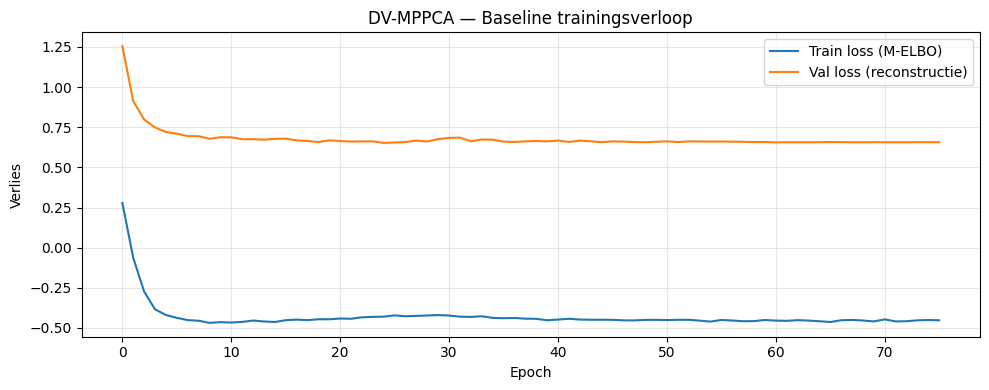

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train loss (M-ELBO)')
if 'val_loss' in history.history:
    ax.plot(history.history['val_loss'], label='Val loss (reconstructie)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Verlies')
ax.set_title('DV-MPPCA — Baseline trainingsverloop')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Stap 4 — Baseline Evaluatie

Anomaliescore per tijdstap: `MSE(x, x_rec) + H(r_n)` — combineert VAE-reconstructiefout en MPPCA-clusteronzekerheid.
Drempel via **POT** (Peak Over Threshold / Gegeneraliseerde Pareto Verdeling) op schone validatiescores.
Zelfde scorekaart als encoder-only en TranAD voor directe vergelijkbaarheid.

In [16]:
def find_event_segments(y):
    segs, in_seg = [], False
    for i, v in enumerate(y):
        if v and not in_seg:
            in_seg, start = True, i
        elif not v and in_seg:
            segs.append((start, i - 1)); in_seg = False
    if in_seg:
        segs.append((start, len(y) - 1))
    return segs

def event_based_metrics(y_true, y_pred):
    true_ev = find_event_segments(y_true)
    pred_ev = find_event_segments(y_pred)
    mt = sum(any(not (pe < ts or ps > te) for ps, pe in pred_ev) for ts, te in true_ev)
    mp = sum(any(not (te < ps or ts > pe) for ts, te in true_ev) for ps, pe in pred_ev)
    er = mt / len(true_ev) if true_ev else 0.0
    ep = mp / len(pred_ev) if pred_ev else 0.0
    ef = 2*ep*er/(ep+er) if ep+er else 0.0
    return {'event_recall': er, 'event_precision': ep, 'event_f1': ef,
            'n_true_events': len(true_ev), 'n_pred_events': len(pred_ev)}


def run_length_filter(y_pred, min_run=3):
    """Verwijdert alarmreeksen korter dan min_run tijdstappen (ruisonderdrukking)."""
    filtered = y_pred.copy().astype(int)
    i = 0
    while i < len(filtered):
        if filtered[i] == 1:
            run_start = i
            while i < len(filtered) and filtered[i] == 1:
                i += 1
            if (i - run_start) < min_run:
                filtered[run_start:i] = 0
        else:
            i += 1
    return filtered


def build_scorecard(y_true, scores, threshold, model_name='DV-MPPCA', min_run=1):
    """Uniforme scorekaart -- zelfde 11 metrieken en volgorde in alle drie pipelines."""
    y_pred = (scores > threshold).astype(int)
    if min_run > 1:
        y_pred = run_length_filter(y_pred, min_run=min_run)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    from sklearn.metrics import fbeta_score
    f2  = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    ba  = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    has_both = len(np.unique(y_true)) > 1
    roc = roc_auc_score(y_true, scores)          if has_both else np.nan
    prc = average_precision_score(y_true, scores) if has_both else np.nan
    evt = event_based_metrics(y_true, y_pred)
    metrics_df = pd.DataFrame([
        {'Metric': 'Precision',             'Value': p},
        {'Metric': 'Recall',                'Value': r},
        {'Metric': 'F1-Score',              'Value': f1},
        {'Metric': 'F2-Score (HVAC Focus)', 'Value': f2},
        {'Metric': 'Balanced Accuracy',     'Value': ba},
        {'Metric': 'MCC',                   'Value': mcc},
        {'Metric': 'ROC-AUC',               'Value': roc},
        {'Metric': 'PR-AUC',                'Value': prc},
        {'Metric': 'Event Recall',          'Value': evt['event_recall']},
        {'Metric': 'Event Precision',       'Value': evt['event_precision']},
        {'Metric': 'Event F1',              'Value': evt['event_f1']},
    ])
    return {
        'threshold': float(threshold),
        'metrics_df': metrics_df,
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'y_pred': y_pred,
        'event_details': evt,
    }

def pot_threshold(scores_clean, risk=0.01, n_tail=None):
    from scipy.stats import genpareto
    s = np.sort(scores_clean)
    if n_tail is None:
        n_tail = max(int(len(s) * 0.10), 30)
    tail = s[-n_tail:] - s[-n_tail]
    shape, loc, scale = genpareto.fit(tail, floc=0)
    u = s[-n_tail]
    q = n_tail / len(s)
    if shape != 0:
        t_hat = u + (scale / shape) * ((risk / q) ** (-shape) - 1)
    else:
        t_hat = u - scale * np.log(risk / q)
    return float(t_hat)


def tune_threshold(scores_tune, y_tune, n_candidates=500):
    """F2-maximalisatie (beta=2) op de gelabelde tune-set.
    Recall weegt 2x zwaarder: bij HVAC is een gemiste fout gevaarlijker dan een vals alarm."""
    from sklearn.metrics import fbeta_score
    percs = np.linspace(50, 99.9, n_candidates)
    candidates = np.percentile(scores_tune, percs)
    best_f2, best_t = 0.0, candidates[0]
    for t in candidates:
        y_pred = (scores_tune > t).astype(int)
        score  = fbeta_score(y_tune, y_pred, beta=2, zero_division=0)
        if score > best_f2:
            best_f2, best_t = score, t
    return float(best_t), float(best_f2)

def plot_scorecard(result, scores, y_true, title='DV-MPPCA', score_label='Anomaliescore'):
    """Uniforme 4-paneel scorekaart -- zelfde structuur in alle drie pipelines."""
    sns.set_theme(style='whitegrid', context='talk')
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
    fig.suptitle(f'{title} -- Scorekaart', fontsize=18, fontweight='bold')

    ax = axes[0, 0]
    ax.plot(scores, lw=1.0, color='#1f77b4', label=score_label)
    ax.axhline(result['threshold'], color='#d62728', ls='--', lw=2,
               label=f'Drempel = {result["threshold"]:.4f}')
    anom = np.where(y_true == 1)[0]
    ax.scatter(anom, scores[anom], s=12, color='#ff7f0e', alpha=0.7, label='GT anomalie', zorder=5)
    ax.set_title('Anomaliescores per tijdstap')
    ax.set_xlabel('Tijdstap')
    ax.set_ylabel(score_label)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.25)

    ax = axes[0, 1]
    for lbl, clr, nm in [(0, '#1f77b4', 'Normaal'), (1, '#d62728', 'Anomalie')]:
        mask = y_true == lbl
        if mask.any():
            sns.histplot(scores[mask], bins=40, kde=True, stat='density',
                         color=clr, alpha=0.45, label=nm, ax=ax)
    ax.axvline(result['threshold'], color='#2ca02c', ls='--', lw=2, label='Drempel')
    ax.set_title('Scoreverdeling per klasse')
    ax.set_xlabel('Score')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.25)

    ax = axes[1, 0]
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                cbar=False, square=True,
                xticklabels=['Pred normaal', 'Pred anomalie'],
                yticklabels=['Echt normaal', 'Echt anomalie'], ax=ax)
    ax.set_title('Confusion matrix')

    ax = axes[1, 1]
    mdf = result['metrics_df'].sort_values('Value', ascending=True)
    sns.barplot(data=mdf, x='Value', y='Metric', hue='Metric',
                dodge=False, palette='viridis', legend=False, ax=ax)
    for i, v in enumerate(mdf['Value']):
        if not np.isnan(v):
            ax.text(min(v + 0.01, 1.05), i, f'{v:.3f}', va='center', fontsize=10)
    ax.set_xlim(0, 1.15)
    ax.set_title('Kernmetrieken')
    ax.set_xlabel('Score')
    plt.show()


In [17]:
def score_components(model, X, batch_size=512):
    """Return raw (MSE, KL, entropy) arrays — one value per timestep."""
    outputs = model.predict(tf.cast(X, tf.float32), batch_size=batch_size, verbose=0)
    x_rec, mu, logvar, z_c, v_n, r_n = outputs
    mse     = np.mean(np.square(X - x_rec), axis=-1)
    kl      = np.maximum(
        -0.5 * np.mean(1 + logvar - np.square(mu) - np.exp(logvar), axis=-1), 0.0)
    entropy = -np.sum(r_n * np.log(r_n + 1e-8), axis=-1)
    return mse, kl, entropy


def compute_score_stats(model, X_clean, batch_size=512):
    """Per-component mean/std on clean data for z-score normalisation."""
    mse, kl, entropy = score_components(model, X_clean, batch_size)
    print("  Score-componenten (normaal bedrijf, voor normalisatie):")
    for nm, arr in [("MSE", mse), ("KL", kl), ("Entropy", entropy)]:
        print(f"    {nm:8s}: mean={arr.mean():.4f}  std={arr.std():.4f}"
              f"  min={arr.min():.4f}  max={arr.max():.4f}")
    return {
        "mse_mean": float(mse.mean()),   "mse_std": float(mse.std())     + 1e-8,
        "kl_mean":  float(kl.mean()),    "kl_std":  float(kl.std())      + 1e-8,
        "ent_mean": float(entropy.mean()),"ent_std": float(entropy.std()) + 1e-8,
    }


def make_score(model, X, stats, smooth_window=6, batch_size=512, verbose=False,
               weights=(1.0, 1.0, 0.0)):
    """Z-score each component, weight, smooth.

    weights[2] (entropy) defaults to 0: entropy is reliably inverted in this
    model (anomalies score lower, not higher) and detecting the flip direction
    requires ground-truth labels — making it unsuitable for an honest scorer.
    """
    mse, kl, entropy = score_components(model, X, batch_size)
    if verbose:
        for nm, arr in [("MSE", mse), ("KL", kl), ("Entropy", entropy)]:
            print(f"  {nm:8s}: mean={arr.mean():.4f}  std={arr.std():.4f}  max={arr.max():.4f}")
    mse_n = (mse     - stats["mse_mean"]) / stats["mse_std"]
    kl_n  = (kl      - stats["kl_mean"])  / stats["kl_std"]
    ent_n = (entropy  - stats["ent_mean"]) / stats["ent_std"]
    score = weights[0]*mse_n + weights[1]*kl_n + weights[2]*ent_n
    if smooth_window > 1:
        hw = smooth_window // 2
        kernel = np.array([max(0, hw - abs(k)) + 1 for k in range(-hw, hw+1)], dtype=float)
        kernel /= kernel.sum()
        score = np.convolve(score, kernel, mode="same")
    return score


def compute_feature_score_stats(model, X_clean, batch_size=512):
    """Per-feature squared error mean/std on clean validation data.

    Used by make_score_feature_max to z-score each feature's reconstruction
    error independently, making the max sensitive to ANY deviant feature.
    """
    outputs = model.predict(tf.cast(X_clean, tf.float32), batch_size=batch_size, verbose=0)
    x_rec = outputs[0]
    sq_err = np.square(X_clean - x_rec)          # (n, F)
    return {
        'mean': sq_err.mean(axis=0),              # (F,)
        'std':  sq_err.std(axis=0) + 1e-8,        # (F,)
    }


def make_score_feature_max(model, X, feat_stats, smooth_window=6, batch_size=512):
    """Max per-feature z-score anomaly score.

    Unlike mean-MSE (which averages over ~48 features, diluting a single
    anomalous sensor ~48×), this takes the maximum z-score across all features
    so that even a fault affecting only one sensor produces a strong signal.
    """
    outputs = model.predict(tf.cast(X, tf.float32), batch_size=batch_size, verbose=0)
    x_rec = outputs[0]
    sq_err = np.square(X - x_rec)                 # (n, F)
    feat_z = (sq_err - feat_stats['mean']) / feat_stats['std']   # (n, F) z-scores
    score  = np.max(feat_z, axis=1)               # (n,) — max over features
    if smooth_window > 1:
        hw = smooth_window // 2
        kernel = np.array([max(0, hw - abs(k)) + 1 for k in range(-hw, hw+1)], dtype=float)
        kernel /= kernel.sum()
        score = np.convolve(score, kernel, mode="same")
    return score


def diagnose_components(model, X, y_true, stats, label=""):
    """Per-component discriminatie: hoe goed scheidt elke component normaal vs anomalie."""
    mse, kl, entropy = score_components(model, X)
    mse_n = (mse     - stats["mse_mean"]) / stats["mse_std"]
    kl_n  = (kl      - stats["kl_mean"])  / stats["kl_std"]
    ent_n = (entropy  - stats["ent_mean"]) / stats["ent_std"]
    print(f"\n{label} — component discriminatie (positieve delta = goed):")
    print(f"  {'Component':16s}  {'Normaal':>10s}  {'Anomalie':>10s}  {'Delta':>10s}  Nota")
    results = {}
    for nm, arr in [("MSE (norm)", mse_n), ("KL (norm)", kl_n), ("Entropy (norm)", ent_n)]:
        n = arr[y_true == 0].mean() if (y_true == 0).any() else float("nan")
        a = arr[y_true == 1].mean() if (y_true == 1).any() else float("nan")
        delta = a - n
        nota = "gebruikt" if nm != "Entropy (norm)" else "NIET gebruikt (inv.)"
        print(f"  {nm:16s}  {n:>10.4f}  {a:>10.4f}  {delta:>+10.4f}  {nota}")
        results[nm] = delta
    return results


def find_best_weights(model, X_tune, y_tune, stats, smooth_window=6):
    """Find best MSE/KL weight ratio on the labelled tune set.

    Entropy is excluded — it is consistently inverted and its flip direction
    can only be determined from ground-truth labels (leakage).
    Returns a 3-tuple (w_mse, w_kl, 0) for use in make_score(weights=...).
    """
    mse, kl, _ = score_components(model, X_tune)
    mse_n = (mse - stats["mse_mean"]) / stats["mse_std"]
    kl_n  = (kl  - stats["kl_mean"])  / stats["kl_std"]

    if len(np.unique(y_tune)) < 2:
        print("  Geen anomalieën in y_tune — standaard gewichten (1, 1, 0).")
        return (1, 1, 0)

    kernel = np.ones(smooth_window) / smooth_window
    best_roc, best_w = 0.0, (1, 1, 0)
    candidates = [(1,0), (0,1), (1,1), (2,1), (1,2), (3,1), (1,3)]
    print("\n  Gewichtszoektocht (MSE, KL) — tune-set, geen entropy, geen flip:")
    print(f"  {'(MSE, KL)':20s}  {'ROC-AUC':>9s}")
    for wm, wk in candidates:
        s = wm*mse_n + wk*kl_n
        if smooth_window > 1:
            s = np.convolve(s, kernel, mode="same")
        roc    = roc_auc_score(y_tune, s)
        marker = " ← best" if roc > best_roc else ""
        print(f"  {str((wm, wk)):20s}  {roc:>9.4f}{marker}")
        if roc > best_roc:
            best_roc, best_w = roc, (wm, wk, 0)
    print(f"\n  Beste gewichten: MSE={best_w[0]}, KL={best_w[1]}"
          f"  (ROC-AUC tune = {best_roc:.4f})")
    return best_w


In [18]:
print("Baseline model — score statistieken op validatieset:")
score_stats_baseline = compute_score_stats(baseline_model, X_val)

scores_val_baseline = make_score(baseline_model, X_val, score_stats_baseline, smooth_window=1)
threshold_baseline_pot = pot_threshold(scores_val_baseline)
print(f"\nPOT-drempel (clean val, geen smoothing): {threshold_baseline_pot:.4f}")

Baseline model — score statistieken op validatieset:
  Score-componenten (normaal bedrijf, voor normalisatie):
    MSE     : mean=0.6768  std=1.3924  min=0.1964  max=10.0434
    KL      : mean=0.2122  std=0.1055  min=0.0890  max=1.0203
    Entropy : mean=0.0113  std=0.0712  min=0.0000  max=0.6927

POT-drempel (clean val, geen smoothing): 9.8859


### 4.1 Synthetische testset inladen

Ground-truth labels voor evaluatie. We splitsen 60/40 (tune/eval) om threshold-lekkage te vermijden.

In [19]:
synth_csv  = f"../02_eda_en_ground_truth/processed/{GEBOUW}_test.csv"
labels_npy = f"../02_eda_en_ground_truth/processed/{GEBOUW}_test_labels.npy"

synth_df = pd.read_csv(synth_csv)
y_labels = np.load(labels_npy).astype(int)
if "timestamp" in synth_df.columns:
    synth_df = synth_df.drop(columns="timestamp")

synth_df = synth_df[kept_features]
X_synth  = scaler.transform(synth_df).astype(np.float32)

min_len  = min(len(X_synth), len(y_labels))
X_synth  = X_synth[:min_len]
y_labels = y_labels[:min_len]

# Adaptieve tune/eval split: splits at the median anomaly position so anomalies
# appear in BOTH halves — avoids the all-anomalies-in-tune collapse from a fixed 60%.
anom_positions = np.where(y_labels == 1)[0]
if len(anom_positions) >= 4:
    split_idx = int(np.median(anom_positions))
else:
    split_idx = min_len // 2   # fallback: even split

X_tune, y_tune = X_synth[:split_idx], y_labels[:split_idx]
X_eval, y_eval = X_synth[split_idx:], y_labels[split_idx:]

print(f"Synthetisch totaal : {X_synth.shape}  | anomalies: {y_labels.sum()}")
print(f"Tune (kalibratie)  : {X_tune.shape}   | anomalies: {y_tune.sum()}")
print(f"Eval (held-out)    : {X_eval.shape}   | anomalies: {y_eval.sum()}")

Synthetisch totaal : (692, 48)  | anomalies: 42
Tune (kalibratie)  : (424, 48)   | anomalies: 20
Eval (held-out)    : (268, 48)   | anomalies: 22


In [20]:
# Score de volledige synthetische testset (voor visualisatie)
scores_synth_baseline = make_score(baseline_model, X_synth, score_stats_baseline,
                                    smooth_window=6, verbose=True)

# Diagnostiek op volledige testset (enkel informatief)
diagnose_components(baseline_model, X_synth, y_labels, score_stats_baseline, "Baseline")

# Gewichtsoptimalisatie UITSLUITEND op tune-set — eval-labels blijven onzichtbaar
best_w_bl = find_best_weights(baseline_model, X_tune, y_tune, score_stats_baseline)

# Score tune- en eval-set met beste gewichten
scores_tune_baseline = make_score(baseline_model, X_tune, score_stats_baseline,
                                   smooth_window=6, weights=best_w_bl)
scores_eval_baseline = make_score(baseline_model, X_eval, score_stats_baseline,
                                   smooth_window=6, weights=best_w_bl)

# Drempel kalibreren op tune-set (met anomalieën); evalueren op held-out eval-set
threshold_baseline, f2_tune_bl = tune_threshold(scores_tune_baseline, y_tune)
print(f"Tune F2-drempel (baseline): {threshold_baseline:.6f}  (F2 tune = {f2_tune_bl:.4f})")

result_baseline = build_scorecard(y_eval, scores_eval_baseline,
                                   threshold_baseline, "DV-MPPCA Baseline")
print(result_baseline["metrics_df"].to_string(index=False))

  MSE     : mean=0.8429  std=0.3620  max=3.5822
  KL      : mean=0.2030  std=0.0855  max=0.4888
  Entropy : mean=0.0610  std=0.1672  max=0.8081

Baseline — component discriminatie (positieve delta = goed):
  Component            Normaal    Anomalie       Delta  Nota
  MSE (norm)            0.0901      0.5717     +0.4816  gebruikt
  KL (norm)            -0.0803     -0.1825     -0.1022  gebruikt
  Entropy (norm)        0.7176      0.4084     -0.3092  NIET gebruikt (inv.)

  Gewichtszoektocht (MSE, KL) — tune-set, geen entropy, geen flip:
  (MSE, KL)               ROC-AUC
  (1, 0)                   0.7933 ← best
  (0, 1)                   0.3225
  (1, 1)                   0.4863
  (2, 1)                   0.5957
  (1, 2)                   0.3985
  (3, 1)                   0.6670
  (1, 3)                   0.3673

  Beste gewichten: MSE=1, KL=0  (ROC-AUC tune = 0.7933)
Tune F2-drempel (baseline): 0.142535  (F2 tune = 0.4372)
               Metric    Value
            Precision 0.160584
   

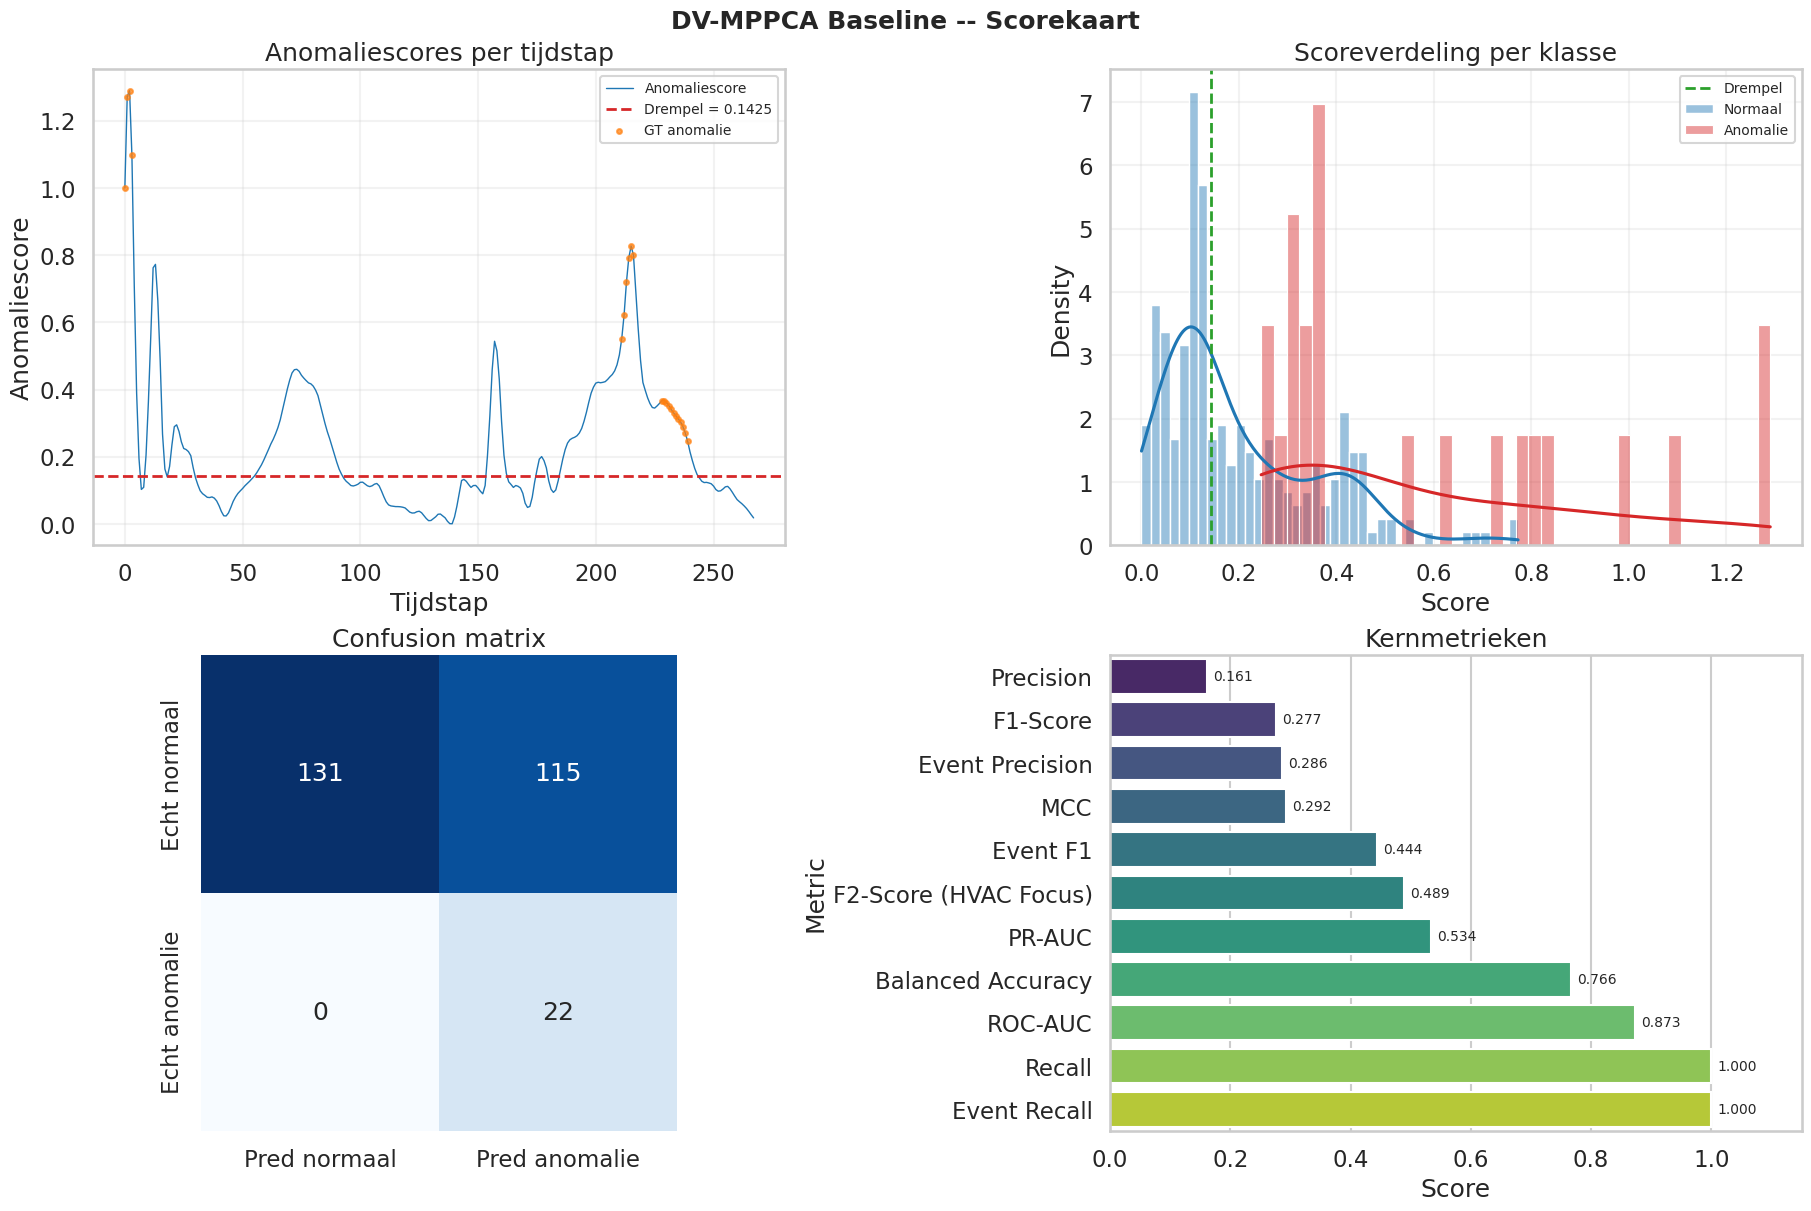

In [21]:
plot_scorecard(result_baseline, scores_eval_baseline, y_eval, "DV-MPPCA Baseline")

## Stap 5 — Hyperparameter Tuning (KerasTuner BayesianOptimization)

Zelfde aanpak als encoder-only en TranAD. Zoekruimte van 6 parameters:
- `latent_dim`: grootte van de latente ruimte $z_c$ 
- `num_components`: aantal MPPCA-clusters $K$
- `hidden_dim`: breedte van encoder/decoder
- `dropout_rate`: regularisatie
- `lr`: Adam leertempo
- `mask_ratio`: fractie gesimuleerde sensoruitval in M-ELBO
- `kl_weight`: Kullback-Leiber gewicht
- `entropy_weigh`: Entropie gewicht

In [22]:
def build_dvmppca_model(hp):
    latent_dim     = hp.Int("latent_dim",       8, 256, step=4)
    num_components = hp.Choice("num_components", [2, 3, 4, 5])
    hidden_dim     = hp.Choice("hidden_dim",     [32, 64, 128, 256])
    dropout_rate   = hp.Float("dropout_rate",    0.0, 0.2, step=0.05)
    lr             = hp.Float("lr",              5e-4, 5e-3, sampling="log")
    mask_ratio     = hp.Choice("mask_ratio",     [0.05, 0.10, 0.15])
    kl_weight      = hp.Choice("kl_weight",      [0.5, 1.0, 2.0])
    entropy_weight = hp.Choice("entropy_weight", [0.0, 0.25, 0.5])  # lower range; not used for scoring

    model = DV_MPPCA_Model(
        input_dim=INPUT_DIM,
        latent_dim=latent_dim,
        num_components=num_components,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
        mask_ratio=mask_ratio,
        kl_weight=kl_weight,
        entropy_weight=entropy_weight,
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(lr))
    model(tf.zeros((1, INPUT_DIM)))
    return model

In [23]:
os.makedirs('tuning_logs/dv_mppca', exist_ok=True)

tuner = kt.BayesianOptimization(
    build_dvmppca_model,
    objective='val_loss',
    max_trials=25,
    num_initial_points=8,
    directory='tuning_logs',
    project_name='dv_mppca',
    overwrite=True,
)
tuner.search_space_summary()

Search space summary
Default search space size: 8
latent_dim (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 256, 'step': 4, 'sampling': 'linear'}
num_components (Choice)
{'default': 2, 'conditions': [], 'values': [2, 3, 4, 5], 'ordered': True}
hidden_dim (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
dropout_rate (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.2, 'step': 0.05, 'sampling': 'linear'}
lr (Float)
{'default': 0.0005, 'conditions': [], 'min_value': 0.0005, 'max_value': 0.005, 'step': None, 'sampling': 'log'}
mask_ratio (Choice)
{'default': 0.05, 'conditions': [], 'values': [0.05, 0.1, 0.15], 'ordered': True}
kl_weight (Choice)
{'default': 0.5, 'conditions': [], 'values': [0.5, 1.0, 2.0], 'ordered': True}
entropy_weight (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.25, 0.5], 'ordered': True}


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [24]:
tuner.search(
    X_train,
    epochs=60,
    batch_size=256,
    validation_data=X_val,
    callbacks=[
        KLAnnealingCallback(warmup_epochs=20),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8, restore_best_weights=True,
            start_from_epoch=20  # wacht tot na KL-warmup
        ),
    ],
    verbose=0,
)

/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00
  [KL anneal] epoch 51: kl_beta = 1.00
  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00
  [KL anneal] epoch 51: kl_beta = 1.00
  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00
  [KL anneal] epoch 51: kl_beta = 1.00
  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00
  [KL anneal] epoch 51: kl_beta = 1.00
  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_bet

/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00
  [KL anneal] epoch 51: kl_beta = 1.00


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


...

  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00
  [KL anneal] epoch 51: kl_beta = 1.00


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


  [KL anneal] epoch 1: kl_beta = 0.05
  [KL anneal] epoch 11: kl_beta = 0.55
  [KL anneal] epoch 21: kl_beta = 1.00
  [KL anneal] epoch 31: kl_beta = 1.00
  [KL anneal] epoch 41: kl_beta = 1.00
  [KL anneal] epoch 51: kl_beta = 1.00


In [25]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Beste hyperparameters:")
for k in ['latent_dim', 'num_components', 'hidden_dim', 'dropout_rate', 'lr', 'mask_ratio']:
    print(f"  {k}: {best_hp.get(k)}")

Beste hyperparameters:
  latent_dim: 256
  num_components: 4
  hidden_dim: 256
  dropout_rate: 0.0
  lr: 0.0005
  mask_ratio: 0.15


## Stap 6 — Beste Model Evaluatie

Train het model met de gevonden hyperparameters volledig opnieuw, evalueer met dezelfde scorekaart en sla artefacten op.

In [26]:
best_model = DV_MPPCA_Model(
    input_dim=INPUT_DIM,
    latent_dim=best_hp.get("latent_dim"),
    num_components=best_hp.get("num_components"),
    hidden_dim=best_hp.get("hidden_dim"),
    dropout_rate=best_hp.get("dropout_rate"),
    mask_ratio=best_hp.get("mask_ratio"),
    kl_weight=best_hp.get("kl_weight"),
    entropy_weight=best_hp.get("entropy_weight"),
)
best_model.compile(optimizer=tf.keras.optimizers.Adam(best_hp.get("lr")))
best_model(tf.zeros((1, INPUT_DIM)))

history_best = best_model.fit(
    X_train,
    epochs=150,
    batch_size=256,
    validation_data=X_val,
    callbacks=[
        KLAnnealingCallback(warmup_epochs=30),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=20, restore_best_weights=True, verbose=1,
            start_from_epoch=30,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5, verbose=1,
        ),
    ],
    verbose=1,
)

  [KL anneal] epoch 1: kl_beta = 0.03
Epoch 1/150


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dv_mppca__model_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: -0.3744 - val_loss: 1.1803 - learning_rate: 5.0000e-04
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: -0.5646 - val_loss: 0.9242 - learning_rate: 5.0000e-04
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: -0.7406 - val_loss: 0.7418 - learning_rate: 5.0000e-04
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: -0.8643 - val_loss: 0.6694 - learning_rate: 5.0000e-04
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: -0.9466 - val_loss: 0.6435 - learning_rate: 5.0000e-04
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: -1.0004 - val_loss: 0.5736 - learning_rate: 5.0000e-04
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: -1.0339 - val_loss: 0.5232 - learning_rate: 5.0000e-04
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: -1.0577 - val_loss: 0.4892 - learning_rate: 5.0000e-04
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: -1.0860 - val_loss: 0.4611 - lea

In [27]:
print("Beste model — score statistieken op validatieset:")
score_stats_best = compute_score_stats(best_model, X_val)

# POT-drempel voor referentie (clean val, geen smoothing)
scores_val_best      = make_score(best_model, X_val, score_stats_best, smooth_window=1)
threshold_best_pot   = pot_threshold(scores_val_best)
print(f"\nPOT-drempel beste model (clean val): {threshold_best_pot:.6f}")

# Gewichtsoptimalisatie uitsluitend op tune-set
best_w_best = find_best_weights(best_model, X_tune, y_tune, score_stats_best)

Beste model — score statistieken op validatieset:
  Score-componenten (normaal bedrijf, voor normalisatie):
    MSE     : mean=0.3506  std=1.2467  min=0.0462  max=8.7388
    KL      : mean=0.2140  std=0.1644  min=0.0941  max=1.2820
    Entropy : mean=1.3683  std=0.0235  min=1.2057  max=1.3854

POT-drempel beste model (clean val): 9.979467

  Gewichtszoektocht (MSE, KL) — tune-set, geen entropy, geen flip:
  (MSE, KL)               ROC-AUC
  (1, 0)                   0.8360 ← best
  (0, 1)                   0.6524
  (1, 1)                   0.7488
  (2, 1)                   0.7874
  (1, 2)                   0.7052
  (3, 1)                   0.8160
  (1, 3)                   0.6910

  Beste gewichten: MSE=1, KL=0  (ROC-AUC tune = 0.8360)


In [28]:
scores_synth_best = make_score(best_model, X_synth, score_stats_best,
                                smooth_window=6, verbose=True, weights=best_w_best)

# Diagnostiek op volledige testset
diagnose_components(best_model, X_synth, y_labels, score_stats_best, "Beste model")

# ── Methode A: gewogen MSE+KL (z-score, gemiddeld over features) ─────────────
scores_tune_best2 = make_score(best_model, X_tune, score_stats_best,
                                smooth_window=6, weights=best_w_best)
scores_eval_best  = make_score(best_model, X_eval, score_stats_best,
                                smooth_window=6, weights=best_w_best)

threshold_best, f2_tune_best = tune_threshold(scores_tune_best2, y_tune)
print(f"\nMethode A — MSE+KL drempel: {threshold_best:.6f}  (F2 tune = {f2_tune_best:.4f})")
result_best = build_scorecard(y_eval, scores_eval_best, threshold_best, "DV-MPPCA Best")
print(result_best["metrics_df"].to_string(index=False))

# ── Methode B: feature-max z-score + run-length filter ───────────────────────
# Per-feature z-score takes the MAX over all features instead of the mean,
# so a fault on a single sensor does not get diluted over 48 features.
# The run-length filter (min_run=3) suppresses isolated single-timestep spikes.
print(f"\n{'='*60}")
print("METHODE B: Feature-max z-score + Run-length filter (min_run=3)")
print("="*60)
feat_stats_best = compute_feature_score_stats(best_model, X_val)
scores_tune_fm  = make_score_feature_max(best_model, X_tune, feat_stats_best, smooth_window=6)
scores_eval_fm  = make_score_feature_max(best_model, X_eval, feat_stats_best, smooth_window=6)

threshold_fm, f2_fm = tune_threshold(scores_tune_fm, y_tune)
print(f"\nMethode B — Feature-max drempel: {threshold_fm:.6f}  (F2 tune = {f2_fm:.4f})")
result_best_fm = build_scorecard(y_eval, scores_eval_fm, threshold_fm,
                                  "DV-MPPCA Best (FeatMax+RL)", min_run=3)
print(result_best_fm["metrics_df"].to_string(index=False))

# ── Kies beste methode op basis van tune-set F2 ───────────────────────────────
print(f"\n{'─'*60}")
print(f"Vergelijking tune-set F2: A (MSE+KL)={f2_tune_best:.4f}  B (FeatMax+RL)={f2_fm:.4f}")
if f2_fm >= f2_tune_best:
    print("→ Methode B gekozen (feature-max + run-length filter)")
    scores_eval_final  = scores_eval_fm
    threshold_final    = threshold_fm
    result_final       = result_best_fm
    score_label_final  = "Max feature z-score"
else:
    print("→ Methode A gekozen (gewogen MSE+KL)")
    scores_eval_final  = scores_eval_best
    threshold_final    = threshold_best
    result_final       = result_best
    score_label_final  = f"MSE×{best_w_best[0]} + KL×{best_w_best[1]}"


  MSE     : mean=0.4639  std=0.2694  max=2.2904
  KL      : mean=0.2369  std=0.0760  max=0.7730
  Entropy : mean=1.3717  std=0.0160  max=1.3862

Beste model — component discriminatie (positieve delta = goed):
  Component            Normaal    Anomalie       Delta  Nota
  MSE (norm)            0.0611      0.5528     +0.4917  gebruikt
  KL (norm)             0.1173      0.4781     +0.3608  gebruikt
  Entropy (norm)        0.1751     -0.3330     -0.5082  NIET gebruikt (inv.)

Methode A — MSE+KL drempel: 0.190867  (F2 tune = 0.5435)
               Metric    Value
            Precision 0.189655
               Recall 1.000000
             F1-Score 0.318841
F2-Score (HVAC Focus) 0.539216
    Balanced Accuracy 0.808943
                  MCC 0.342323
              ROC-AUC 0.954361
               PR-AUC 0.669681
         Event Recall 1.000000
      Event Precision 0.666667
             Event F1 0.800000

METHODE B: Feature-max z-score + Run-length filter (min_run=3)

Methode B — Feature-max drem

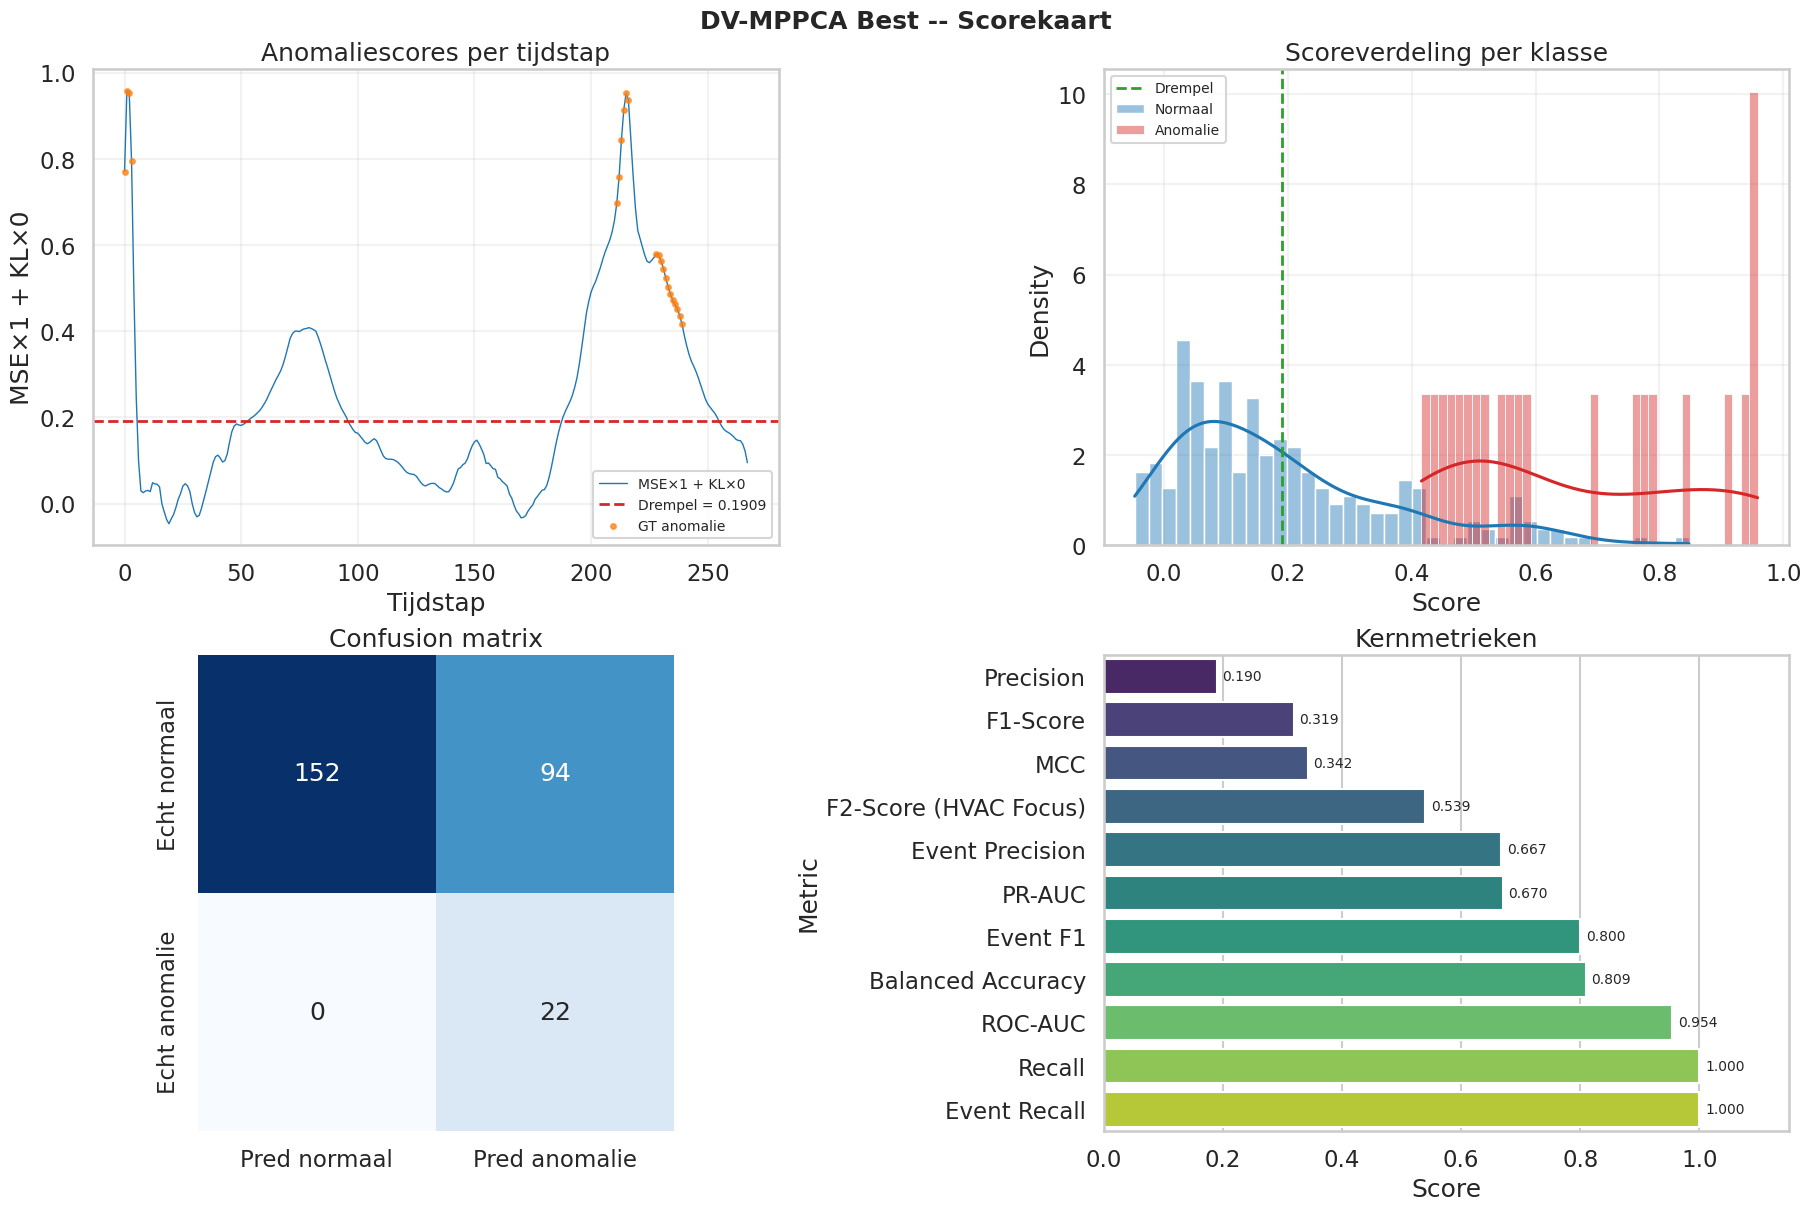

In [29]:
plot_scorecard(result_final, scores_eval_final, y_eval,
               title="DV-MPPCA Best", score_label=score_label_final)

### 6.1 Artefacten opslaan

Model, scaler en featurelijst opslaan voor productie-inferentie.

In [30]:
today = date.today().isoformat()
os.makedirs('models',   exist_ok=True)
os.makedirs('dv_mppca', exist_ok=True)

model_path    = f'models/dv-mppca-{GEBOUW}-{today}-best.weights.h5'
scaler_path   = f'dv_mppca/scaler_{GEBOUW}.pkl'
features_path = f'dv_mppca/features_{GEBOUW}.json'

best_model.save_weights(model_path)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
with open(features_path, 'w') as f:
    json.dump(list(kept_features), f)

print(f"Model    : {model_path}")
print(f"Scaler   : {scaler_path}")
print(f"Features : {features_path}")

Model    : models/dv-mppca-dunant1-2026-05-15-best.weights.h5
Scaler   : dv_mppca/scaler_dunant1.pkl
Features : dv_mppca/features_dunant1.json


## Stap 7 — Inferentie

Laad het opgeslagen model en detecteer anomalieën in nieuwe, ongelabelde meetdata.

In [31]:
def predict_anomalies(X_new, model, score_stats, threshold,
                      smooth_window=6, batch_size=512,
                      weights=(1.0, 1.0, 0.0)):
    """Score new data and return binary anomaly mask."""
    scores     = make_score(model, X_new, score_stats,
                             smooth_window=smooth_window,
                             batch_size=batch_size,
                             weights=weights)
    is_anomaly = (scores > threshold).astype(int)
    return scores, is_anomaly


def load_dvmppca(model_path, features_path, scaler_path, input_dim,
                 latent_dim=12, num_components=4, hidden_dim=64,
                 dropout_rate=0.1, mask_ratio=0.10,
                 kl_weight=1.0, entropy_weight=0.5):
    with open(features_path) as f:
        feats = json.load(f)
    with open(scaler_path, "rb") as f:
        sc = pickle.load(f)
    m = DV_MPPCA_Model(input_dim=input_dim, latent_dim=latent_dim,
                        num_components=num_components, hidden_dim=hidden_dim,
                        dropout_rate=dropout_rate, mask_ratio=mask_ratio,
                        kl_weight=kl_weight, entropy_weight=entropy_weight)
    m.compile(optimizer="adam")
    m(tf.zeros((1, input_dim)))
    m.load_weights(model_path)
    return m, sc, feats

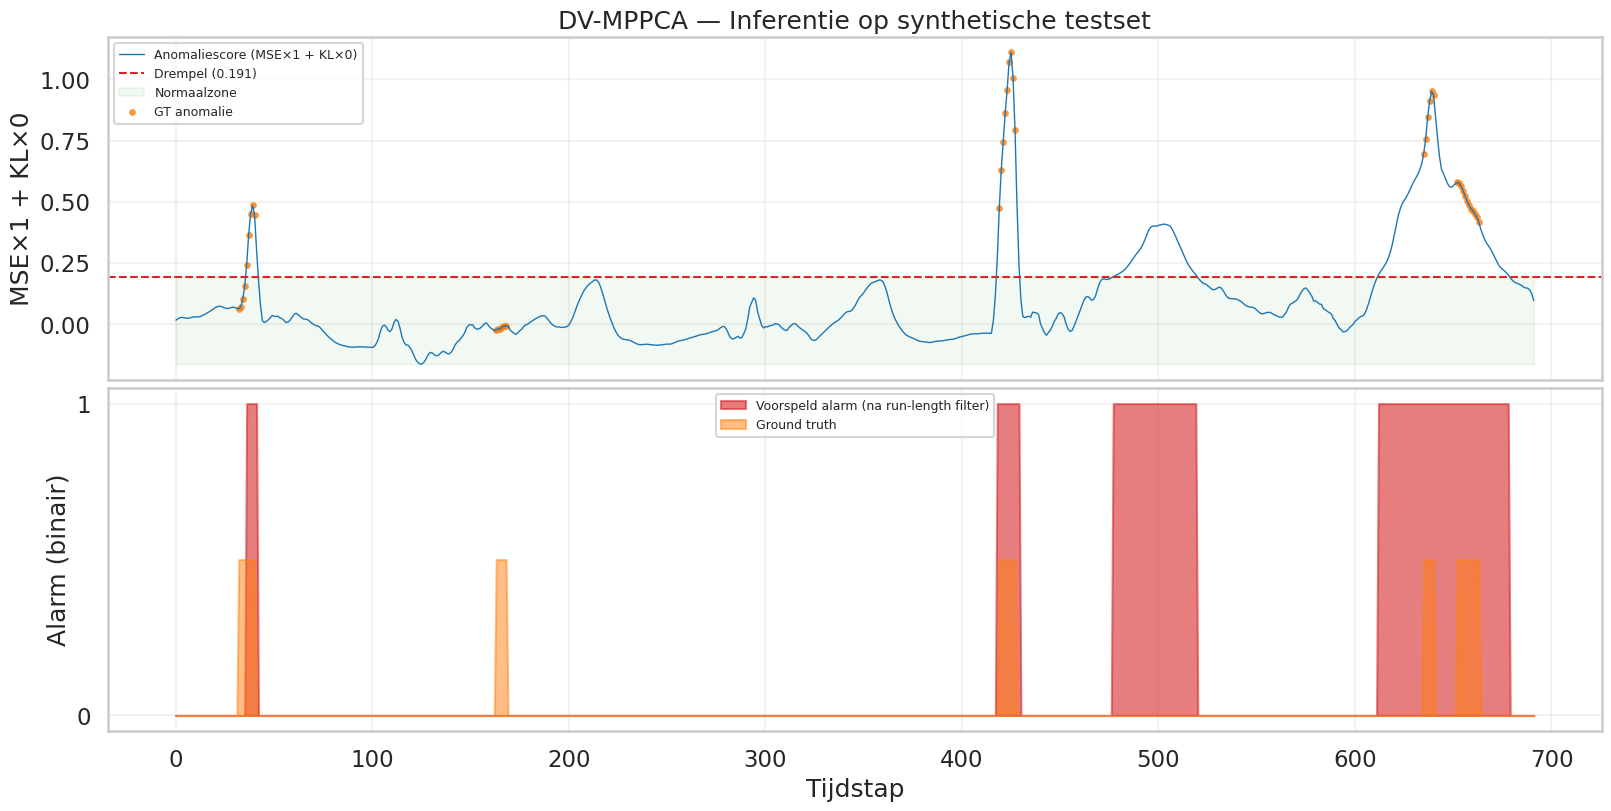

Voorspeld alarm  : 128/692 (18.5%)
Ground truth     : 42/692  (6.1%)


In [32]:
# Inferentie op de volledige synthetische testset met de gekozen scoringsmethode
if score_label_final == "Max feature z-score":
    scores_demo = make_score_feature_max(best_model, X_synth, feat_stats_best, smooth_window=6)
    threshold_demo = threshold_fm
else:
    scores_demo = make_score(best_model, X_synth, score_stats_best,
                              smooth_window=6, weights=best_w_best)
    threshold_demo = threshold_best

anomalies_raw  = (scores_demo > threshold_demo).astype(int)
anomalies_demo = run_length_filter(anomalies_raw, min_run=MIN_RUN)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True, constrained_layout=True)

ax = axes[0]
ax.plot(scores_demo, lw=1, color="#1f77b4", label=f"Anomaliescore ({score_label_final})")
ax.axhline(threshold_demo, color="#d62728", ls="--", lw=1.5,
           label=f"Drempel ({threshold_demo:.3f})")
ax.fill_between(range(len(scores_demo)), scores_demo.min(), threshold_demo,
                alpha=0.05, color="green", label="Normaalzone")
anom_idx = np.where(y_labels == 1)[0]
ax.scatter(anom_idx, scores_demo[anom_idx], s=12, color="#ff7f0e",
           alpha=0.7, label="GT anomalie")
ax.set_ylabel(score_label_final)
ax.set_title("DV-MPPCA — Inferentie op synthetische testset")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

ax = axes[1]
ax.fill_between(range(len(anomalies_demo)), 0, anomalies_demo,
                color="#d62728", alpha=0.6, label="Voorspeld alarm (na run-length filter)")
ax.fill_between(range(len(y_labels)), 0, [v * 0.5 for v in y_labels],
                color="#ff7f0e", alpha=0.5, label="Ground truth")
ax.set_ylabel("Alarm (binair)")
ax.set_xlabel("Tijdstap")
ax.set_yticks([0, 1])
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.show()

n_pred = int(anomalies_demo.sum())
n_gt   = int(y_labels.sum())
n_tot  = len(anomalies_demo)
print(f"Voorspeld alarm  : {n_pred}/{n_tot} ({n_pred/n_tot:.1%})")
print(f"Ground truth     : {n_gt}/{n_tot}  ({n_gt/n_tot:.1%})")


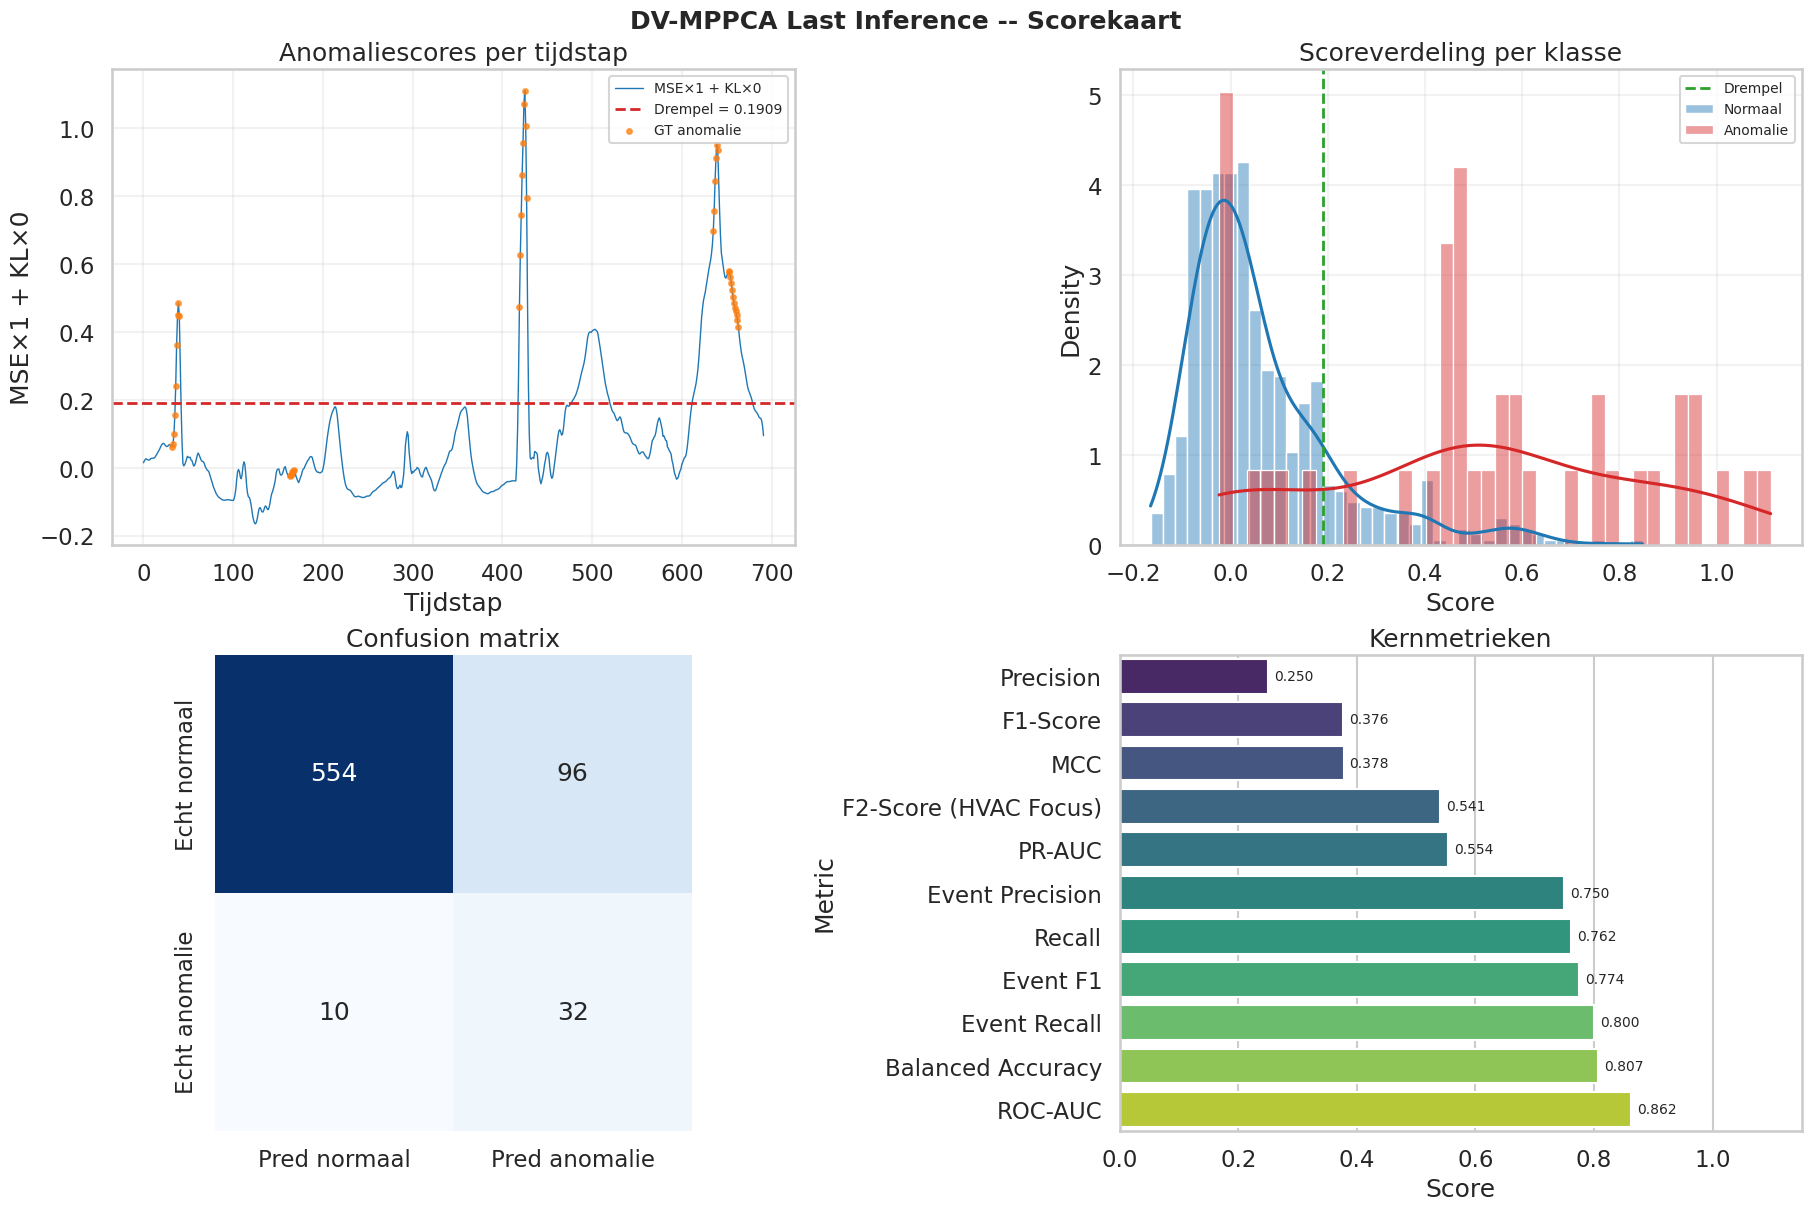

In [33]:
result_infer = build_scorecard(y_labels, scores_demo, threshold_demo, "DV-MPPCA Last Inference", min_run=MIN_RUN)

plot_scorecard(
    result_infer,
    scores_demo,
    y_labels,
    title="DV-MPPCA Last Inference",
    score_label=score_label_final,
)